Banks operate in a highly competitive environment where acquiring a new customer is significantly more expensive than retaining an existing one. Customer attrition (also known as customer churn) directly impacts a banking institution's revenue, profitability, and long-term customer lifetime value.

When customers discontinue their relationship with a bank, the institution loses:

- Future transaction revenue
- Credit card spending revenue
- Loan and investment prospects

Therefore, identifying customers who are likely to leave the bank before attrition occurs is a critical business objective.
Our bank in particular has observed that a portion of their credit card customers are discontinuing their relationship with the institution.
Currently, the bank lacks an early-warning system to proactively identify customers at risk of attrition.

Therefore, we want to develop a predictive analytics solution capable of identifying customers that are likely to churn.
The main objective behind this project is to predict whether a customer is likely to leave a bank based on demographics, relationship, account, and transaction behavior data.

In [1]:
#let's begin our project first with importing basic libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Let's load the dataset first
#we are using a bank churners dataset for this project
bank_df=pd.read_csv("BankChurners.csv")
#let's identify the target variable by viewing a few records
bank_df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [5]:
#Now let's check the shape of the dataset to determine the number of records and attributes
bank_df.shape

(10127, 21)

In [7]:
#Let's understand the datatype of each attribute
bank_df.info()
#The dataset contains both numerical and categorical attributes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

In [9]:
#Converting all attributes to a list would help access them easily
bank_df.columns.to_list()

['CLIENTNUM',
 'Attrition_Flag',
 'Customer_Age',
 'Gender',
 'Dependent_count',
 'Education_Level',
 'Marital_Status',
 'Income_Category',
 'Card_Category',
 'Months_on_book',
 'Total_Relationship_Count',
 'Months_Inactive_12_mon',
 'Contacts_Count_12_mon',
 'Credit_Limit',
 'Total_Revolving_Bal',
 'Avg_Open_To_Buy',
 'Total_Amt_Chng_Q4_Q1',
 'Total_Trans_Amt',
 'Total_Trans_Ct',
 'Total_Ct_Chng_Q4_Q1',
 'Avg_Utilization_Ratio']

In [11]:
#Let's split the numerical and categorical features and perform independent analysis on each feature set
num_features = bank_df.select_dtypes(include=['int64','float64']).columns.tolist()
num_features

['CLIENTNUM',
 'Customer_Age',
 'Dependent_count',
 'Months_on_book',
 'Total_Relationship_Count',
 'Months_Inactive_12_mon',
 'Contacts_Count_12_mon',
 'Credit_Limit',
 'Total_Revolving_Bal',
 'Avg_Open_To_Buy',
 'Total_Amt_Chng_Q4_Q1',
 'Total_Trans_Amt',
 'Total_Trans_Ct',
 'Total_Ct_Chng_Q4_Q1',
 'Avg_Utilization_Ratio']

In [13]:
#Categorical features
cat_features = bank_df.select_dtypes(include=['object']).columns.tolist()
cat_features


['Attrition_Flag',
 'Gender',
 'Education_Level',
 'Marital_Status',
 'Income_Category',
 'Card_Category']

In [15]:
#Let's use descriptive derive certain basic insights and potential outliers
bank_df.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


- Here we can see that clientnum is used as a unique identifier and doeset add much value for making prediction
- It would eventually be dropped before we begin with the model building phase
- The mean number of dependents are 2 which suggests that there could be high spending requirements by certain households
- Cutomers on an average spend atleast 36 months with the bank
- Each customer mostly holds 3-4 banking products
- Each customer on an average has contacted the bank twice in the past 12 months

In [18]:
#Lets determine the categories of our target variable
bank_df["Attrition_Flag"].value_counts()
#This tells us that our target varibale 2 categories:
#1.Existing Customer- customers that stay with the bank
#2.Attrited Customer- customers that have left the bank

#We also determined that there is class imbalance  between our categories as attrited customers only form a small proportion of our dataset compared to the existing customers
#Hence while selecing a model we might need to account for this imabalance

Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

In [20]:
#Lets convert the category types as a percentage of total customers
round(bank_df['Attrition_Flag'].value_counts(normalize=True)*100,2)

Attrition_Flag
Existing Customer    83.93
Attrited Customer    16.07
Name: proportion, dtype: float64

In [28]:
#Now let's check for missing values
bank_df.isnull().sum()
#The dataset we obtained contains no missing values

CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

Dataset contains 10,127 customer records and 21 features. 
The target variable is Attrition_Flag.

The target variable, Attrition_Flag, indicates whether a customer has remained with the bank or attrited.


Features can be categorized into:
- Demographics
- Relationship
- Engagement
- Credit
- Transaction

There were no missing values for any feature

Target variable distribution indicates that there is significant class imbalance


We will now focus on data cleaning and preparing the dataset for further analysis and model building 

In [22]:
#we will perform all the data cleaning operations within a copy of the dataset
bank_clean=bank_df.copy()

In [24]:
#let's verify our copy
bank_clean.shape
#our copy contain the same dimensions as original churners dataset

(10127, 21)

In [26]:
#Clientnum is a unique identifier and hence we must remove that column first as discussed earlier.
bank_clean.drop("CLIENTNUM",axis=1,inplace=True)

In [28]:
bank_clean.head()
#we can observe that the clientnum attribue has been dropped

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [30]:
#we will be using the copy dataset for further analysis so we must
#reassign the numerial and cat features since they too need to be instantiated
num_features= bank_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_features

['Customer_Age',
 'Dependent_count',
 'Months_on_book',
 'Total_Relationship_Count',
 'Months_Inactive_12_mon',
 'Contacts_Count_12_mon',
 'Credit_Limit',
 'Total_Revolving_Bal',
 'Avg_Open_To_Buy',
 'Total_Amt_Chng_Q4_Q1',
 'Total_Trans_Amt',
 'Total_Trans_Ct',
 'Total_Ct_Chng_Q4_Q1',
 'Avg_Utilization_Ratio']

In [32]:
cat_features=bank_clean.select_dtypes(include=["object"]).columns.tolist()
cat_features

['Attrition_Flag',
 'Gender',
 'Education_Level',
 'Marital_Status',
 'Income_Category',
 'Card_Category']

We have completed the cleaning and preprocessing phase, and we are now proceeding to the EDA phase

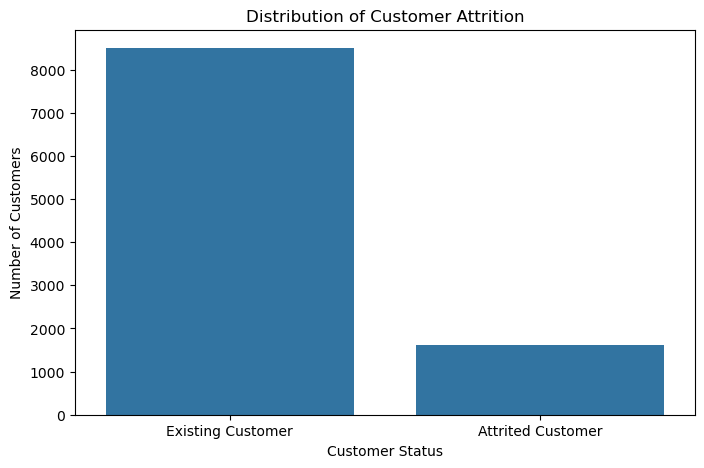

In [53]:
#We are beginning our analysis with the customer demographics group first
#We will be studying the distribution of each variable followed by understanding the correlations between them and determining how variables relate to attrition
#This group comprises of: (Age,Gender,Income,Education,Dependents)
#But first lets switch to Target variable visualization to understand the distribution across our target
plt.figure(figsize=(8,5))
sns.countplot(data=bank_clean,x='Attrition_Flag')
plt.title('Distribution of Customer Attrition')
plt.xlabel('Customer Status')
plt.ylabel('Number of Customers')
plt.show()

- The majority of customers remain active with the bank, while a smaller proportion have attrited.
- Although only a minority of customers have attrited, these customers represent a significant business concern because replacing existing customers is generally more expensive than retaining them.


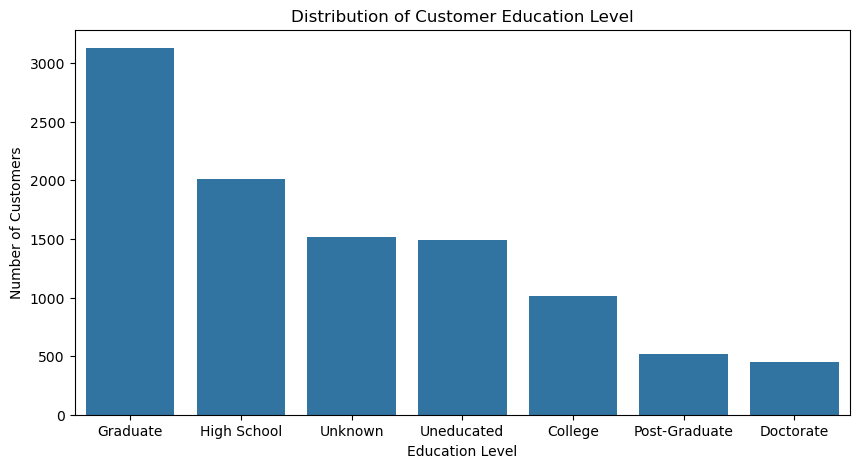

In [42]:
#let's analyze the education level atribute
round(bank_clean["Education_Level"].value_counts(normalize=True) * 100,2)
#this code helps map each education category as a percentage of customers the bank serves
plt.figure(figsize=(10,5))
sns.countplot(data=bank_clean,x="Education_Level",order=bank_clean["Education_Level"].value_counts().index)
plt.title("Distribution of Customer Education Level")
plt.xlabel("Education Level")
plt.ylabel("Number of Customers")
plt.show()


- The dominance of graduate and high school customers suggests that the bank's credit card offerings primarily appeal to customers with mainstream educational backgrounds.
- Overall, the customer base is distributed across multiple education levels, suggesting that the bank serves a diverse population rather than targeting a specific educational group.

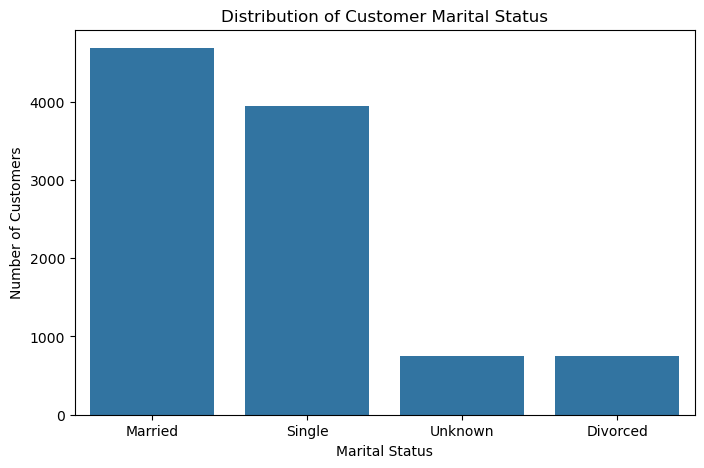

In [44]:
#Let's analyze maritial status
plt.figure(figsize=(8,5))
sns.countplot(data=bank_clean,x="Marital_Status",order=bank_clean["Marital_Status"].value_counts().index)
plt.title("Distribution of Customer Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Number of Customers")
plt.show()

- The predominance of married and single customers suggests that the bank's credit card products cater to a broad retail customer base rather than a niche demographic.
- Marital status may influence financial responsibilities, spending behavior, and product usage.

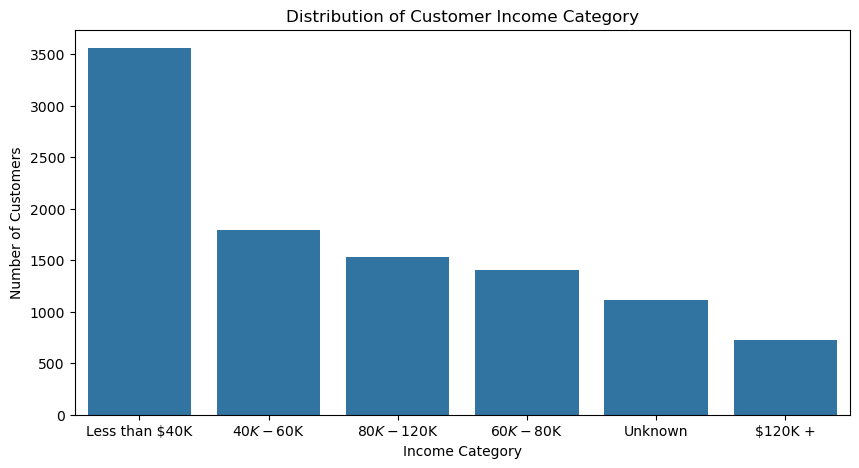

In [46]:
#Lets now analyze income category
plt.figure(figsize=(10,5))
sns.countplot(data=bank_clean,x="Income_Category",order=bank_clean["Income_Category"].value_counts().index)
plt.title("Distribution of Customer Income Category")
plt.xlabel("Income Category")
plt.ylabel("Number of Customers")
plt.show()

- The income distribution suggests that the bank's credit card portfolio is primarily targeted toward the mass retail banking segment, with a large proportion of customers earning less than $60K annually.
- Although affluent customers ($120K+) represent a smaller share of the portfolio, they may still contribute significantly to the bank's revenue due to higher spending and larger credit limits.

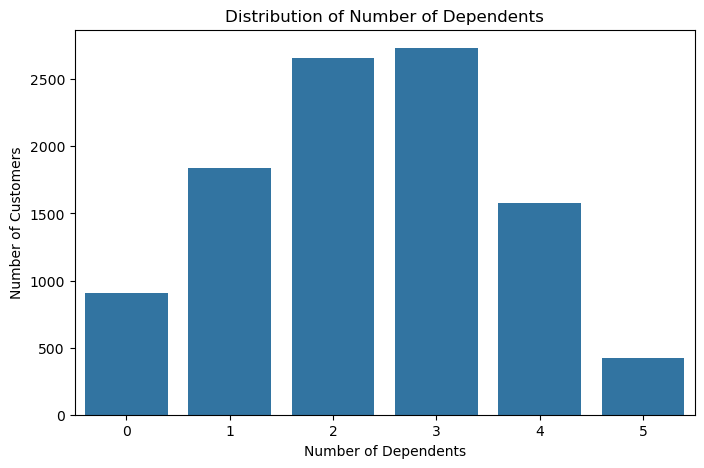

In [49]:
#Let's analyze the dependent count feature
plt.figure(figsize=(8,5))
sns.countplot(data=bank_clean,x="Dependent_count",order=sorted(bank_clean["Dependent_count"].unique()))
plt.title("Distribution of Number of Dependents")
plt.xlabel("Number of Dependents")
plt.ylabel("Number of Customers")
plt.show()

- The customer base primarily consists of individuals supporting small to medium-sized families, with most customers having between 2 and 3 dependents. This indicates that the bank's retail credit card products appeal largely to customers with family responsibilities.
- Family size may influence spending habits, savings behavior, and credit requirements

  We are done analyzing the demographic group of this dataset

Now we shall analyze the customer relationship segment which comprises of Months_on_book and Total_Relationship_Count attributes.

In [56]:
# Summary Statistics to determine the numerical relationships
bank_clean["Months_on_book"].describe()

count    10127.000000
mean        35.928409
std          7.986416
min         13.000000
25%         31.000000
50%         36.000000
75%         40.000000
max         56.000000
Name: Months_on_book, dtype: float64

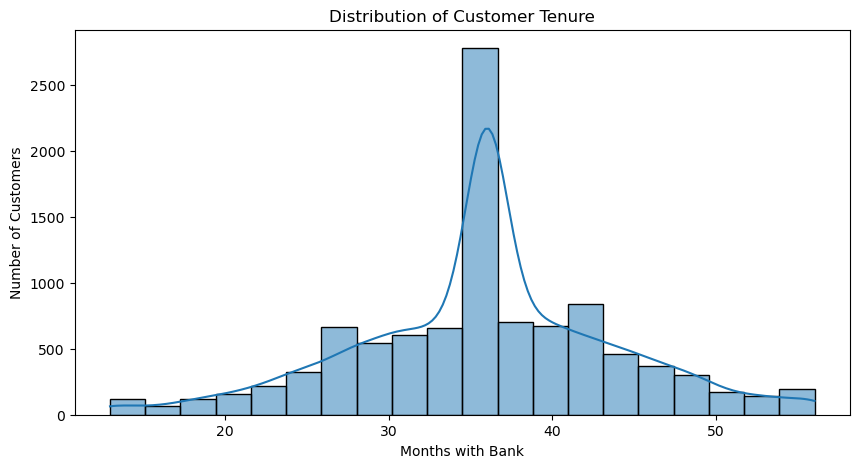

In [58]:
# Distribution Plot for determining the distribution
plt.figure(figsize=(10,5))
sns.histplot(data=bank_clean,x="Months_on_book",kde=True,bins=20)
plt.title("Distribution of Customer Tenure")
plt.xlabel("Months with Bank")
plt.ylabel("Number of Customers")
plt.show()

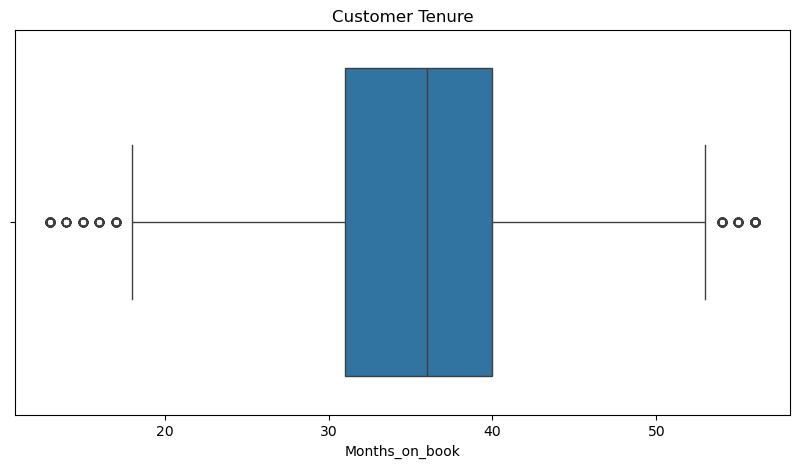

In [60]:
# Boxplot for outlier detection
plt.figure(figsize=(10,5))
sns.boxplot(data=bank_clean,x="Months_on_book")
plt.title("Customer Tenure")
plt.show()

In [62]:
#Now lets move to total relationship count
bank_clean["Total_Relationship_Count"].describe()

count    10127.000000
mean         3.812580
std          1.554408
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          6.000000
Name: Total_Relationship_Count, dtype: float64

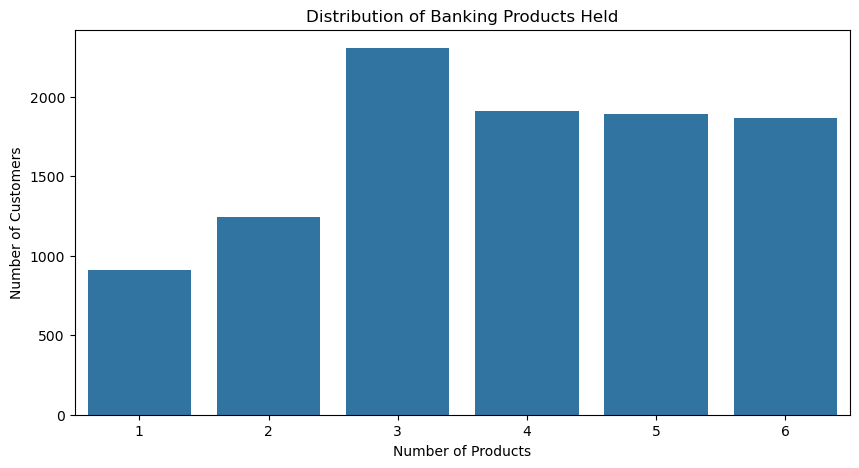

In [64]:
# Distribution Plot
plt.figure(figsize=(10,5))
sns.countplot(data=bank_clean,x="Total_Relationship_Count")
plt.title("Distribution of Banking Products Held")
plt.xlabel("Number of Products")
plt.ylabel("Number of Customers")
plt.show()

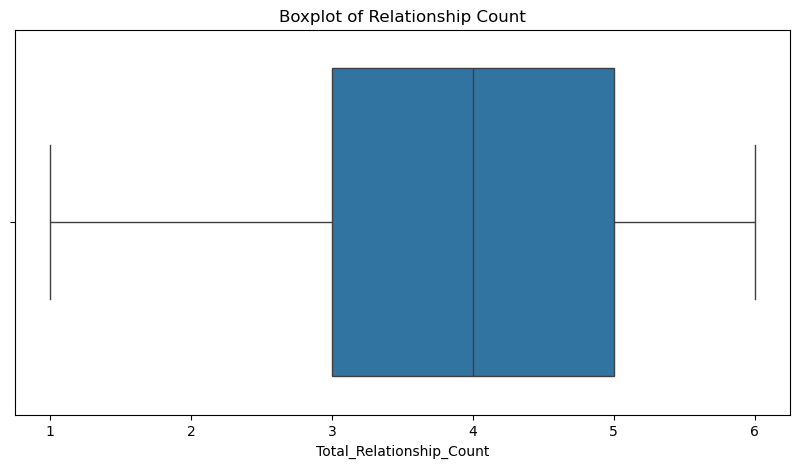

In [66]:
# Boxplot for outlier detection
plt.figure(figsize=(10,5))
sns.boxplot(data=bank_clean,x="Total_Relationship_Count")
plt.title("Boxplot of Relationship Count")
plt.show()

- Here we can see that a particular customer spends 35 months (3 years) with the same bank, with minimum tenure being 13 months and maximum tenure being 56 months
- Customers spending less than 20 months with a bank and those spending more than 50 months are identified as outliers, but we wont count them as outliers since these are important results
- On an average a customer spends around 32-40 months with a particular bank
- On average, each customer has purchased 3-4 products from the same bank with each customer having atleast one product and atmost 6 products
- There are no outliers with the relationship attribute

Now we are focusing on customer engagement analysis, which comprises of:(months inactive and contacts count)

In [71]:
# Number of months in a year for which customers have been inactive
bank_clean["Months_Inactive_12_mon"].describe()

count    10127.000000
mean         2.341167
std          1.010622
min          0.000000
25%          2.000000
50%          2.000000
75%          3.000000
max          6.000000
Name: Months_Inactive_12_mon, dtype: float64

In [73]:
#This will tell us the how many customers have been inactive for number of months
bank_clean["Months_Inactive_12_mon"].value_counts().sort_index()

Months_Inactive_12_mon
0      29
1    2233
2    3282
3    3846
4     435
5     178
6     124
Name: count, dtype: int64

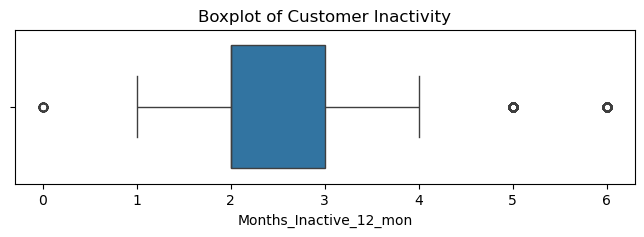

In [75]:
#Boxplot for outlier detection
plt.figure(figsize=(8,2))
sns.boxplot(data=bank_clean,x="Months_Inactive_12_mon")
plt.title("Boxplot of Customer Inactivity")
plt.show()

In [77]:
# This code will tell us how frequently customers have contacted the bank in the past year
bank_clean["Contacts_Count_12_mon"].describe()

count    10127.000000
mean         2.455317
std          1.106225
min          0.000000
25%          2.000000
50%          2.000000
75%          3.000000
max          6.000000
Name: Contacts_Count_12_mon, dtype: float64

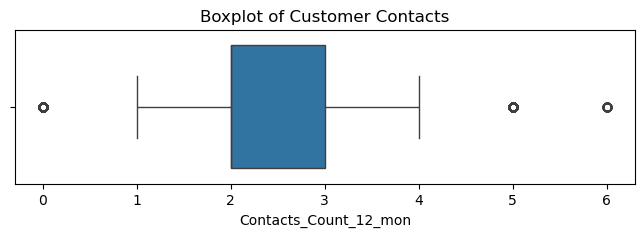

In [87]:
#Outlier detection
plt.figure(figsize=(8,2))
sns.boxplot(data=bank_clean,x="Contacts_Count_12_mon")
plt.title("Boxplot of Customer Contacts")
plt.show()

- We realized that the average inactivity within a year is 2 months and maximum inactivity is 6 months
- There are 124 customers that have been inactive for 6 months, which is not a good sign for a bank, as it can contribute significantly to attrition rates, which in turn can contribute to loss of revenue and lifetime values
- We have around 4000 customers that stay inactive for 2-3 months, which again could impact attrition
- The average number of times a customer contacts the bank is just 2, which could either be positive or a massive concern
- There are also customers that have never contacted the bank, which indicates that such customers are bound to leave that bank sooner or later


Now we are dealing with the credit behaviour analysis. This section would tell us how customers use their credit facilities

In [81]:
# The credit limit reflects the maximum amount of credit extended to a customer
#This serves as an indicator of credit worthiness
bank_clean["Credit_Limit"].describe()

count    10127.000000
mean      8631.953698
std       9088.776650
min       1438.300000
25%       2555.000000
50%       4549.000000
75%      11067.500000
max      34516.000000
Name: Credit_Limit, dtype: float64

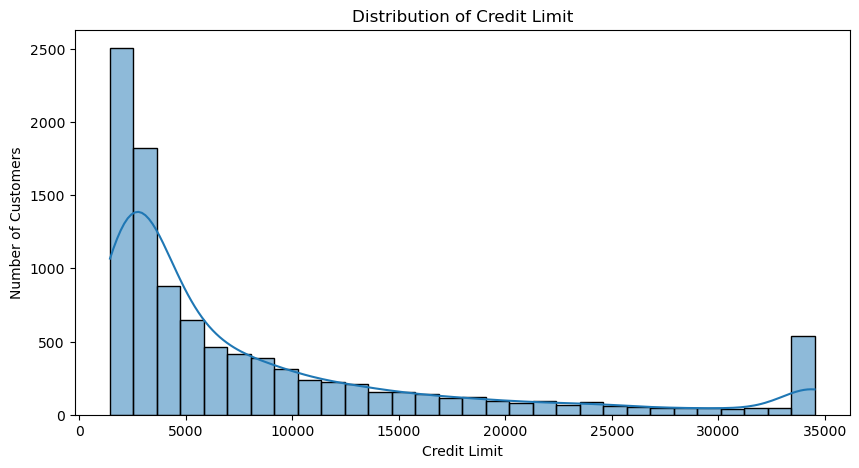

In [83]:
#Let's plot the distribution spread of credit limit
plt.figure(figsize=(10,5))
sns.histplot(data=bank_clean,x="Credit_Limit",bins=30,kde=True)
plt.title("Distribution of Credit Limit")
plt.xlabel("Credit Limit")
plt.ylabel("Number of Customers")
plt.show()

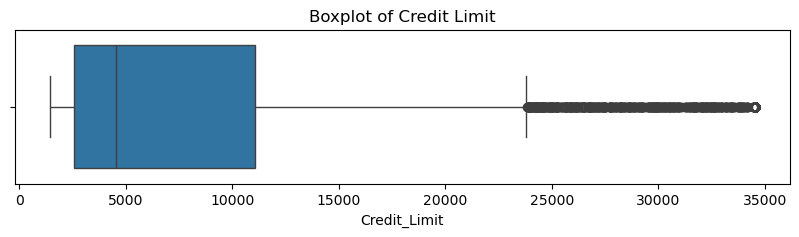

In [85]:
#Boxplot analysis for outlier detection
plt.figure(figsize=(10,2))
sns.boxplot(data=bank_clean,x="Credit_Limit")
plt.title("Boxplot of Credit Limit")
plt.show()

- Here we can conclude that the maximum credit lent to a customer is close to 35 k
- The average credit limit is around 9k and most of the customers have credit limit within the range 4k-11k
- Credit limits over 25k are treated as outliers and we have quite a few customers having their credit limits over 25k
- The distribution suggests that customers prefer having lesser credit limit

Now let's move to studying the transaction behavior for customers. This would help us examine how customers use their credit cards in terms of spending and transaction activity.

In [90]:
#Lets begin with analyzing how much do customers spend through their credit cards over the last 12 months?
bank_clean["Total_Trans_Amt"].describe()

count    10127.000000
mean      4404.086304
std       3397.129254
min        510.000000
25%       2155.500000
50%       3899.000000
75%       4741.000000
max      18484.000000
Name: Total_Trans_Amt, dtype: float64

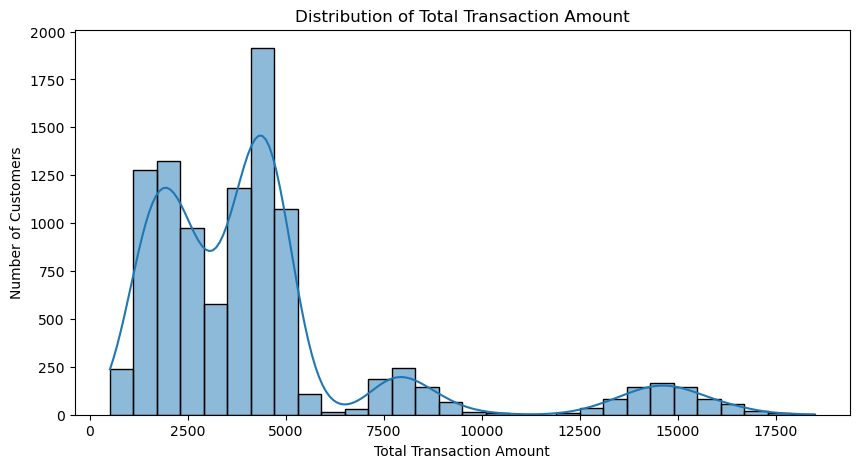

In [92]:
#Let's now study the distribution of this attribute 
plt.figure(figsize=(10,5))
sns.histplot(data=bank_clean,x="Total_Trans_Amt",bins=30,kde=True)
plt.title("Distribution of Total Transaction Amount")
plt.xlabel("Total Transaction Amount")
plt.ylabel("Number of Customers")
plt.show()

- This study suggests us that customers have spent very minimal amounts through their credit cards
- Very rarely have customers spent over 10k through credit cards, which could mean that customers are reluctant to have high credits

Now we are switching our focus to understanding the relationship between features and the target variable.
Until now, we just studied the distribution of features independently. Now we must relate them to the attrition flag

In [105]:
#We'll begin first with the customer demographics vs Attrtion analysis
#Customer demographics comprosises of:
#Customer_Age
#Gender
#Education_Level
#Marital_Status
#Income_Category
#Dependent_count

In [96]:
#Let's study age vs attrition
bank_clean.groupby("Attrition_Flag")["Customer_Age"].describe()
#Here we observed that youngest customer from the attrited category is 68 years old
#The oldest customer of the existing category is 73 years old

,count,mean,std,min,25%,50%,75%,max
Attrition_Flag,,,,,,,,
Attrited Customer,1627.0,46.659496,7.665652,26.0,41.0,47.0,52.0,68.0
Existing Customer,8500.0,46.262118,8.081157,26.0,41.0,46.0,52.0,73.0


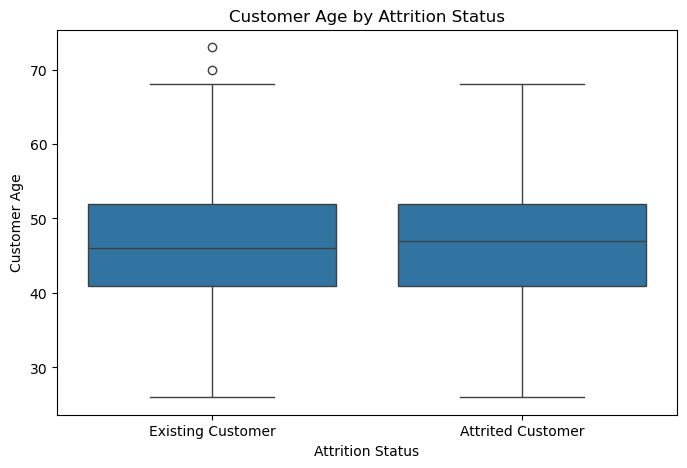

In [98]:
#We use box plot to study the distribution across both categories
plt.figure(figsize=(8,5))
sns.boxplot(data=bank_clean,x="Attrition_Flag",y="Customer_Age")
plt.title("Customer Age by Attrition Status")
plt.xlabel("Attrition Status")
plt.ylabel("Customer Age")
plt.show()

In [100]:
#Now let's study gender with attrition
round(pd.crosstab(bank_clean["Gender"],bank_clean["Attrition_Flag"],normalize="index") * 100,2)

Attrition_Flag,Attrited Customer,Existing Customer
Gender,,
F,17.36,82.64
M,14.62,85.38


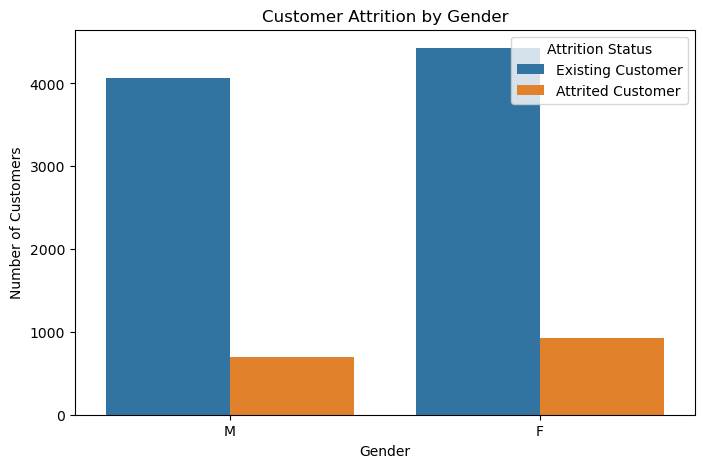

In [102]:
#Countplot for determinng the impact
plt.figure(figsize=(8,5))
sns.countplot(data=bank_clean,x="Gender",hue="Attrition_Flag")
plt.title("Customer Attrition by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.legend(title="Attrition Status")
plt.show()

In [104]:
round(pd.crosstab(bank_clean["Education_Level"],bank_clean["Attrition_Flag"],normalize="index") * 100,2)


Attrition_Flag,Attrited Customer,Existing Customer
Education_Level,,
College,15.20,84.80
Doctorate,21.06,78.94
Graduate,15.57,84.43
High School,15.20,84.80
Post-Graduate,17.83,82.17
Uneducated,15.94,84.06
Unknown,16.85,83.15


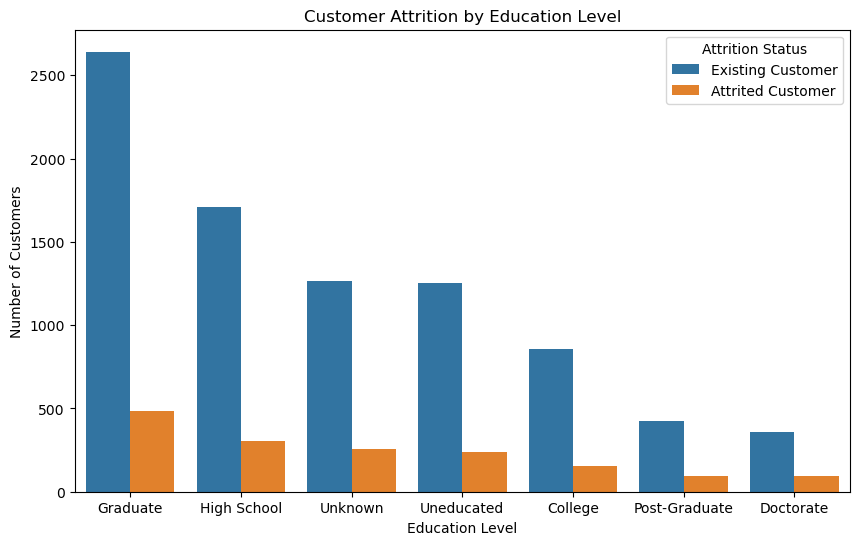

In [106]:
#Lets now study the relationship between education level and attrition
plt.figure(figsize=(10,6))
sns.countplot(data=bank_clean,x="Education_Level",hue="Attrition_Flag",order=bank_clean["Education_Level"].value_counts().index)
plt.title("Customer Attrition by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Number of Customers")
plt.legend(title="Attrition Status")
plt.show()

In [108]:
#Now lets analyze the relationship between marital status and attriton
round(pd.crosstab(bank_clean["Marital_Status"],bank_clean["Attrition_Flag"],normalize="index") * 100,2)

Attrition_Flag,Attrited Customer,Existing Customer
Marital_Status,,
Divorced,16.18,83.82
Married,15.13,84.87
Single,16.94,83.06
Unknown,17.22,82.78


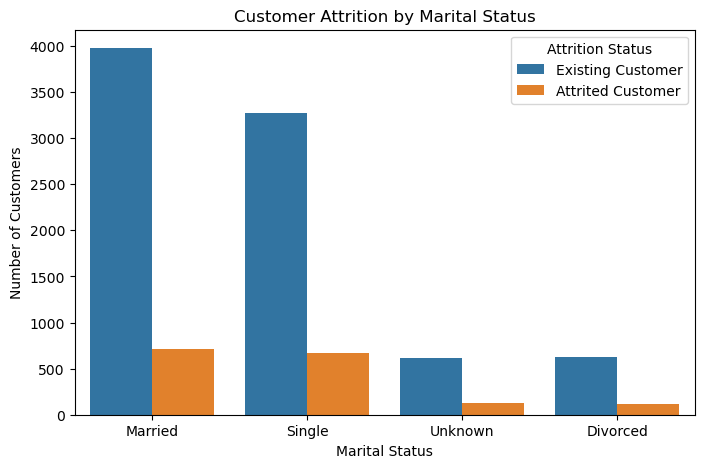

In [121]:
plt.figure(figsize=(8,5))
sns.countplot(data=bank_clean,x="Marital_Status",hue="Attrition_Flag",order=bank_clean["Marital_Status"].value_counts().index)
plt.title("Customer Attrition by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Number of Customers")
plt.legend(title="Attrition Status")
plt.show()

In [110]:
#Now let's study if income category affects attrition rates
round(pd.crosstab(bank_clean["Income_Category"],bank_clean["Attrition_Flag"],
        normalize="index") * 100,2)

Attrition_Flag,Attrited Customer,Existing Customer
Income_Category,,
$120K +,17.33,82.67
$40K - $60K,15.14,84.86
$60K - $80K,13.48,86.52
$80K - $120K,15.77,84.23
Less than $40K,17.19,82.81
Unknown,16.82,83.18


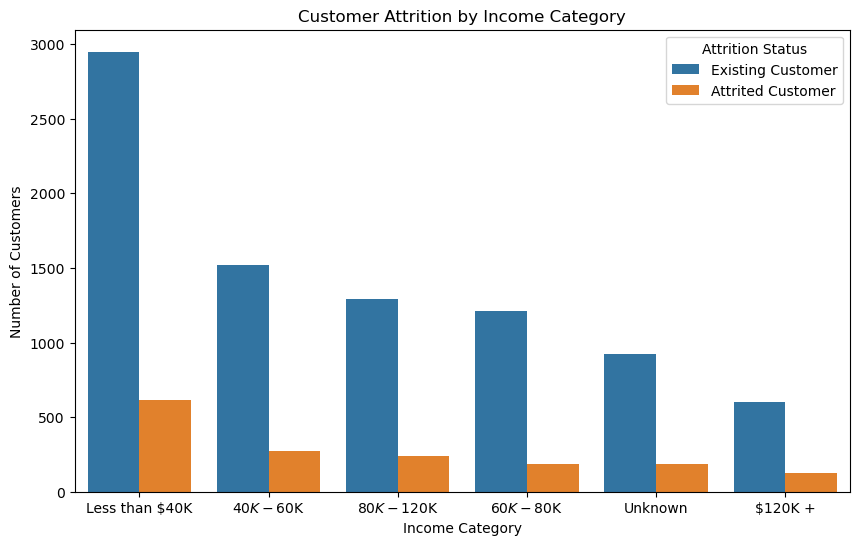

In [125]:
plt.figure(figsize=(10,6))
sns.countplot(data=bank_clean,x="Income_Category",hue="Attrition_Flag",order=bank_clean["Income_Category"].value_counts().index)
plt.title("Customer Attrition by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Number of Customers")
plt.legend(title="Attrition Status")
plt.show()

In [112]:
#Now lets analyze dependent count vs attrition
round(pd.crosstab(bank_clean["Dependent_count"],bank_clean["Attrition_Flag"],normalize="index") * 100,2)

Attrition_Flag,Attrited Customer,Existing Customer
Dependent_count,,
0,14.93,85.07
1,14.64,85.36
2,15.71,84.29
3,17.64,82.36
4,16.52,83.48
5,15.09,84.91


The demographic analysis examined whether customer attrition varies across different demographic characteristics. These variables help determine whether specific customer segments are inherently more likely to leave the bank or whether attrition is driven by other behavioral factors.

- Customer age showed a slight variation between existing and attrited customers, indicating that age alone is not a strong differentiator of customer attrition.
- Gender exhibited nearly identical attrition rates across male and female customers, suggesting that gender has minimal influence on customer retention.
- Education level showed only modest differences in attrition across educational groups, with no single category experiencing disproportionately high customer loss.
- Marital status displayed relatively consistent attrition rates across married, single, divorced, and unknown categories, indicating a limited relationship with churn.
- Income Category demonstrated some variation in attrition across income segments; however, the differences were not substantial enough to conclude that income alone is a primary driver of customer attrition.
- Dependent Count showed only minor fluctuations in attrition rates across different family sizes, suggesting that household responsibilities have a limited impact on customer retention.

The analysis indicates that demographic characteristics alone are not strong predictors of customer attrition. Therefore, demographic information should be considered as supporting context rather than the primary basis for customer retention strategies.

Now we shall be visualizing the impact of customer relationship on atrition 

In [114]:
bank_clean.groupby("Attrition_Flag")["Months_on_book"].agg(['count', 'mean', 'median', 'min', 'max']).round(2)

,count,mean,median,min,max
Attrition_Flag,,,,,
Attrited Customer,1627,36.18,36.0,13,56
Existing Customer,8500,35.88,36.0,13,56


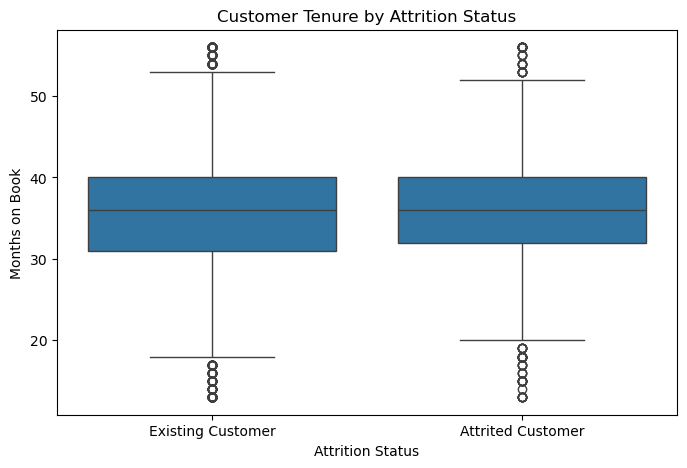

In [116]:
plt.figure(figsize=(8,5))
sns.boxplot(data=bank_clean,x="Attrition_Flag",y="Months_on_book")
plt.title("Customer Tenure by Attrition Status")
plt.xlabel("Attrition Status")
plt.ylabel("Months on Book")
plt.show()

In [118]:
round(pd.crosstab(bank_clean["Total_Relationship_Count"],bank_clean["Attrition_Flag"],normalize="index") * 100,2)

Attrition_Flag,Attrited Customer,Existing Customer
Total_Relationship_Count,,
1,25.60,74.40
2,27.84,72.16
3,17.35,82.65
4,11.77,88.23
5,12.00,88.00
6,10.50,89.50


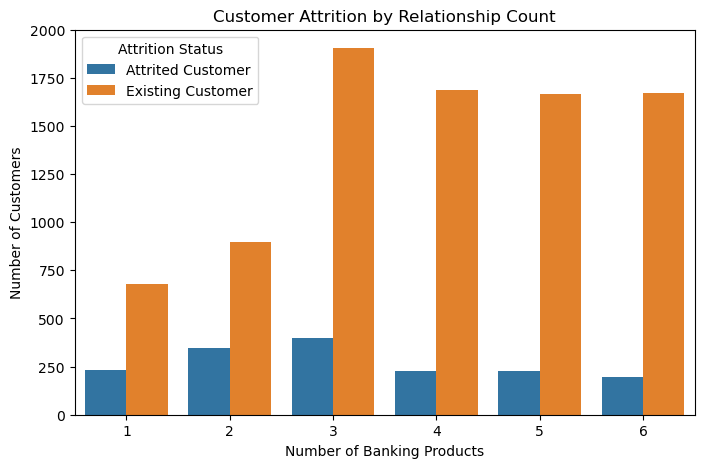

In [120]:
plt.figure(figsize=(8,5))
sns.countplot(data=bank_clean,x="Total_Relationship_Count",hue="Attrition_Flag",order=sorted(bank_clean["Total_Relationship_Count"].unique()))
plt.title("Customer Attrition by Relationship Count")
plt.xlabel("Number of Banking Products")
plt.ylabel("Number of Customers")
plt.legend(title="Attrition Status")
plt.show()

- The average tenure of attrited customers (36.18 months) is almost identical to that of existing customers (35.88 months).
- Both groups have the same median tenure (36 months) and identical minimum and maximum values.
- This suggests that customer tenure alone is not a strong predictor of attrition.
- Customers having only 1-2 products with the bank are most likely to churn which  suggests that customers having fewer products have weaker engagement with the bank and can easily switch to competitors.
- The attrition rate steadily declines as customers hold more products.
- Encouraging customers to adopt additional banking products (such as savings accounts, loans, investments, or credit cards) could significantly reduce churn.

Now let's visulaize customer activity vs attrition

In [124]:
round(pd.crosstab(bank_clean["Months_Inactive_12_mon"],bank_clean["Attrition_Flag"],normalize="index") * 100,2)

Attrition_Flag,Attrited Customer,Existing Customer
Months_Inactive_12_mon,,
0,51.72,48.28
1,4.48,95.52
2,15.39,84.61
3,21.48,78.52
4,29.89,70.11
5,17.98,82.02
6,15.32,84.68


In [126]:
round(pd.crosstab(bank_clean["Contacts_Count_12_mon"],bank_clean["Attrition_Flag"],normalize="index") * 100,2)

Attrition_Flag,Attrited Customer,Existing Customer
Contacts_Count_12_mon,,
0,1.75,98.25
1,7.20,92.80
2,12.49,87.51
3,20.15,79.85
4,22.63,77.37
5,33.52,66.48
6,100.00,0.00


- Customers with one inactive month have the lowest attrition rate (4.48%), indicating that brief periods of inactivity are common and do not necessarily signal customer disengagement.
- Attrition rises steadily from 2 to 4 inactive months which suggests that prolonged inactivity is associated with an increased risk of customer churn
- There is a strong positive relationship between the number of customer contacts and attrition. As the number of contacts increases, the likelihood of churn also increases.
- Frequent customer contact should not be interpreted as healthy engagement


Now let's study the customer credit behaviour agains attrition

In [130]:
bank_clean.groupby("Attrition_Flag")["Credit_Limit"].agg(['count','mean','median','min','max']).round(2)

,count,mean,median,min,max
Attrition_Flag,,,,,
Attrited Customer,1627,8136.04,4178.0,1438.3,34516.0
Existing Customer,8500,8726.88,4643.5,1438.3,34516.0


In [132]:
bank_clean.groupby("Attrition_Flag")["Total_Revolving_Bal"].agg(['count','mean','median','min','max']).round(2)

,count,mean,median,min,max
Attrition_Flag,,,,,
Attrited Customer,1627,672.82,0.0,0,2517
Existing Customer,8500,1256.60,1364.0,0,2517


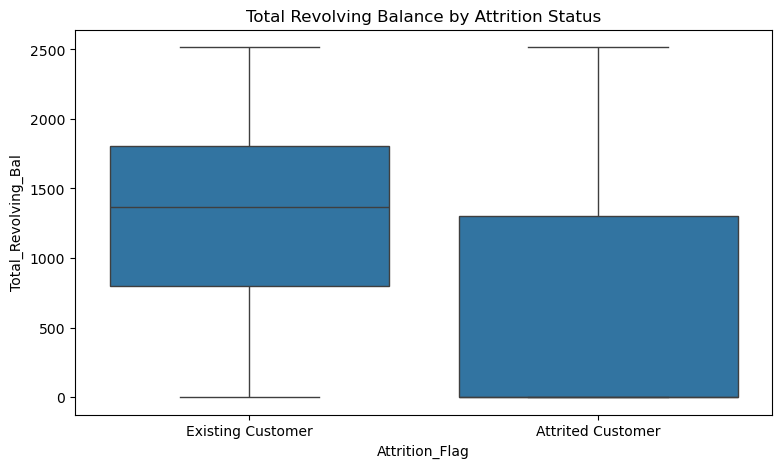

In [134]:
plt.figure(figsize=(9,5))
sns.boxplot(data=bank_clean,x="Attrition_Flag",y="Total_Revolving_Bal")
plt.title("Total Revolving Balance by Attrition Status")
plt.show()

In [136]:
bank_clean.groupby("Attrition_Flag")["Avg_Utilization_Ratio"].agg(['count','mean','median','min','max']).round(3)

,count,mean,median,min,max
Attrition_Flag,,,,,
Attrited Customer,1627,0.162,0.000,0.0,0.999
Existing Customer,8500,0.296,0.211,0.0,0.994


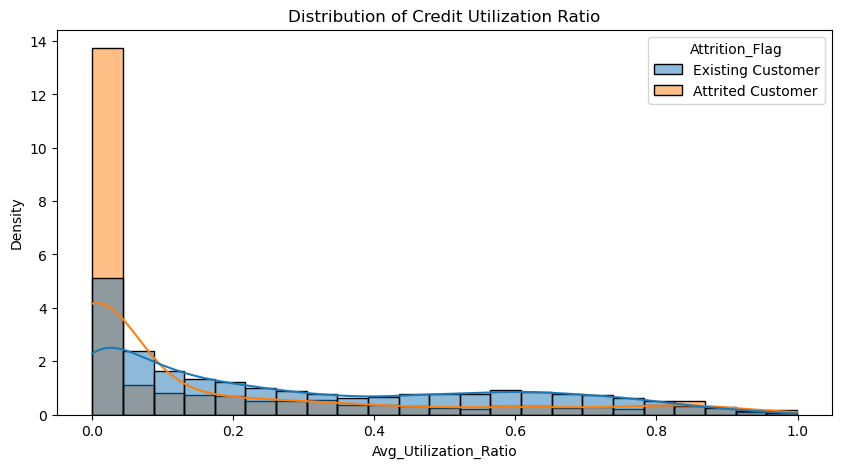

In [141]:
plt.figure(figsize=(10,5))
sns.histplot(data=bank_clean,x="Avg_Utilization_Ratio",hue="Attrition_Flag",kde=True,stat="density",common_norm=False)
plt.title("Distribution of Credit Utilization Ratio")
plt.show()

- This analysis examined whether customers' credit usage patterns influence their likelihood of attrition
- Credit Limit showed only moderate variation between existing and attrited customers, indicating that the amount of credit assigned to a customer is not, by itself, a strong driver of attrition.
- The median revolving balance for attrited customers is 0, meaning that at least 50% of customers who left the bank had no revolving balance at all.
- Many customers appear to stop using their credit card before they eventually leave the bank. A prolonged zero revolving balance may therefore serve as an early indicator of disengagement.
- The bank should monitor customers whose revolving balances remain consistently low or zero and proactively encourage card usage.
- Customers who regularly use a meaningful portion of their available credit are significantly more engaged with the bank's credit card product and demonstrate greater loyalty.
- Low or zero credit utilization appears to be a strong behavioral signal of declining customer engagement.
- Declining credit usage may therefore serve as an early warning signal for customer churn


Now lets study transaction behaviour vs attrition

In [145]:
bank_clean.groupby("Attrition_Flag")["Total_Trans_Amt"].agg(['count','mean','median','min','max']).round(2)

,count,mean,median,min,max
Attrition_Flag,,,,,
Attrited Customer,1627,3095.03,2329.0,510,10583
Existing Customer,8500,4654.66,4100.0,816,18484


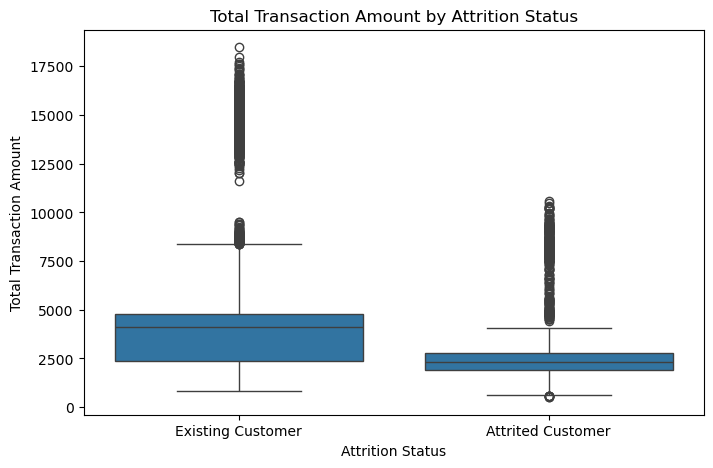

In [147]:
plt.figure(figsize=(8,5))
sns.boxplot(data=bank_clean,x="Attrition_Flag",y="Total_Trans_Amt")
plt.title("Total Transaction Amount by Attrition Status")
plt.xlabel("Attrition Status")
plt.ylabel("Total Transaction Amount")
plt.show()

In [149]:
bank_clean.groupby("Attrition_Flag")["Total_Trans_Ct"].agg(['count','mean','median','std','min','max']).round(2)

,count,mean,median,std,min,max
Attrition_Flag,,,,,,
Attrited Customer,1627,44.93,43.0,14.57,10,94
Existing Customer,8500,68.67,71.0,22.92,11,139


- A typical retained customer spends almost 1.8 times more than a typical attrited customer, suggesting that declining transaction activity is a strong indicator of weakening customer engagement.
- Customers with consistently low transaction amounts appear considerably more likely to attrite.
- The bank should continuously monitor customers' annual transaction amounts and identify individuals whose spending declines significantly below peer-group levels
- The transaction behavior analysis demonstrates that customer spending is strongly associated with retention. Existing customers consistently generate substantially higher transaction values than attrited customers, indicating that active card usage reflects a stronger and more valuable banking relationship.
- Multiple transaction-related variables were available in the dataset. To avoid repetitive analyses and maintain focus on business interpretation, Total_Trans_Amt was selected as the primary representative metric for transaction behavior

We have completed the EDA phase for this project and we now proceed to correlation analysis and hypotheis testing where we shall determine the relationship between numerical and categorical features and identify the strongest correalting attribute with our target variable.

In [154]:
#Let's convert the num features to a dataframe to access the corr() method.
#correlation analysis is done for numerical features
num_df = bank_clean.select_dtypes(include=['int64', 'float64'])
corr_matrix = num_df.corr()

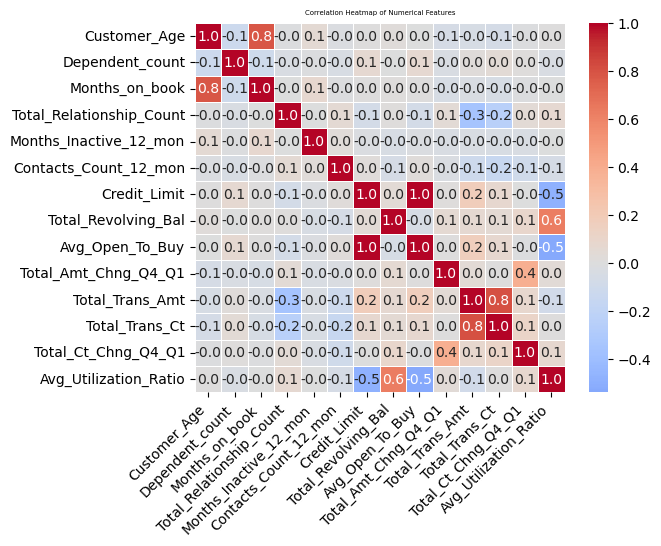

In [156]:
#We will be using a heatmap visual to study the correlations
sns.heatmap(corr_matrix,annot=True,fmt=".1f",cmap="coolwarm",center=0,linewidths=0.4,square=True)
plt.title("Correlation Heatmap of Numerical Features", fontsize=5)
plt.xticks(rotation=45,ha='right')
plt.show()

- A strong positive relationship exists between Customer Age and Months on Book.
- Older customers have generally had more time to build a longer relationship with the bank. As customer age increases, account tenure also tends to increase.
- Customers who perform more transactions also tend to generate higher total transaction amounts.
- Higher transaction frequency naturally leads to higher cumulative spending
- Credit-related variables naturally demonstrate the strongest correlations
- Overall, the heatmap suggests limited multicollinearity, implying that most features are likely to provide independent predictive value
- The correlation analysis revealed that the majority of numerical features exhibit weak to moderate relationships, indicating that the dataset contains diverse and complementary information

We are now preparing the dataset for model buiding, so we might apply some transformations or drop few columns to reduce dimensonality or we could aply scaling to boost model performance in this stage of the project.

In [261]:
# Encode target variable into a binary format to make it compatible with machine learning algorithms.
bank_clean["Attrition_Flag"] = bank_clean["Attrition_Flag"].map({"Existing Customer": 0,"Attrited Customer": 1})

In [263]:
#Verify whether the categories have been encoded
bank_clean["Attrition_Flag"].value_counts()
#Existing has been mapped to o and Attrited has been mapped to 1 as seen using value counts

Attrition_Flag
0    8500
1    1627
Name: count, dtype: int64

Most classification algorithms cannot directly process text labels. Binary encoding transforms the target variable into a numerical format while preserving its meaning

In [265]:
#Now similarly let's encode some categorical variables as well
#We will be using one hot encoding since none of these variables have a true numerical order.
# One-Hot Encode categorical variables
bank_clean = pd.get_dummies(bank_clean,columns=["Gender","Education_Level","Marital_Status","Income_Category","Card_Category"],
drop_first=True,dtype=int)

In [269]:
bank_clean.head()

,Attrition_Flag,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,...,Marital_Status_Single,Marital_Status_Unknown,Income_Category_$40K - $60K,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Income_Category_Unknown,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
0,0,45,3,39,5,1,3,12691.0,777,11914.0,...,0,0,0,1,0,0,0,0,0,0
1,0,49,5,44,6,1,2,8256.0,864,7392.0,...,1,0,0,0,0,1,0,0,0,0
2,0,51,3,36,4,1,0,3418.0,0,3418.0,...,0,0,0,0,1,0,0,0,0,0
3,0,40,4,34,3,4,1,3313.0,2517,796.0,...,0,1,0,0,0,1,0,0,0,0
4,0,40,3,21,5,1,0,4716.0,0,4716.0,...,0,0,0,1,0,0,0,0,0,0


In [271]:
bank_clean.shape
#Here there are 33 columns due to the encoding performed

(10127, 33)

We are done with preprocessing the data and now we switch to model building 

In [274]:
#Let's first split the target variable and predictors
X = bank_clean.drop("Attrition_Flag", axis=1)
y = bank_clean["Attrition_Flag"]
print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape :", y.shape)
#Having 32 columns in feature matrix helps verify that target variable has been dropped

Feature Matrix Shape: (10127, 32)
Target Vector Shape : (10127,)


In [276]:
#Npw lets go for an 80-20 split followed by stratification to account for class imbalance
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (8101, 32)
X_test : (2026, 32)
y_train: (8101,)
y_test : (2026,)


In [280]:
#we are using logistic regression first and for that we must perform feature scaling 
from sklearn.preprocessing import StandardScaler
# Initializing scaler object
scaler = StandardScaler()
# Let's fit on on training data
X_train_scaled = scaler.fit_transform(X_train)
# Applying the same transformation to test data
X_test_scaled = scaler.transform(X_test)

In [282]:
from sklearn.linear_model import LogisticRegression
# Initialize the model
log_model = LogisticRegression(random_state=42)
# Train the model
log_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [284]:
# Training predictions
y_train_pred = log_model.predict(X_train_scaled)

In [288]:
y_test_pred = log_model.predict(X_test_scaled)

In [292]:
from sklearn.metrics import accuracy_score
# Training Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.4f}")

Training Accuracy: 0.9062


In [294]:
# Testing Accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Testing Accuracy: {test_accuracy:.4f}")

Testing Accuracy: 0.8998


The difference between the training and testing accuracy is only 0.7 percentage points, which is very small. This indicates that the Logistic Regression model has learned the underlying patterns in the training data while maintaining consistent performance on unseen data.

The next model that we are using is Decision Trees. Unlike Logistic Regression, Decision Trees can capture complex interactions between variables without requiring feature scaling.

In [298]:
from sklearn.tree import DecisionTreeClassifier
# Initialize the model
dt_model = DecisionTreeClassifier(random_state=42)
# Train the model directly since we dont need feature scaling here
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [300]:
# Training predictions
y_train_pred_dt = dt_model.predict(X_train)
# Testing predictions
y_test_pred_dt = dt_model.predict(X_test)

In [302]:
#Training accuracy
from sklearn.metrics import accuracy_score
train_accuracy_dt = accuracy_score(y_train, y_train_pred_dt)
print(f"Training Accuracy: {train_accuracy_dt:.4f}")

Training Accuracy: 1.0000


In [304]:
test_accuracy_dt = accuracy_score(y_test, y_test_pred_dt)
print(f"Testing Accuracy: {test_accuracy_dt:.4f}")

Testing Accuracy: 0.9334


Our default decison tree has depicted overfitting since there is massive performance gap between training and testing accuracies. So i will be hypertuning the parameters of decision tree to see the impact it has on the accuracies

In [307]:
#decison tree hyperparameter tuning
#we will be using grid search cv for evaluating all specified hyperparameter combinations. Grid Search helps select the configuration that performs best using cross-validation.
#let's first define the parameters grid
param_grid = {'criterion': ['gini', 'entropy'],'max_depth': [3, 5, 7, 10, None],'min_samples_split': [2, 5, 10, 20],
'min_samples_leaf': [1, 2, 4, 8],
'max_features': [None, 'sqrt', 'log2']}

In [311]:
from sklearn.model_selection import GridSearchCV
d1t = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(estimator=d1t,param_grid=param_grid,cv=5,scoring='accuracy',n_jobs=-1)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10, None],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4, 8],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='accuracy')

In [313]:
#Let us now determine the best parameters
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'criterion': 'gini', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [317]:
#Training our decison tree using the best parameters
best_d1t= grid_search.best_estimator_
best_d1t.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, min_samples_leaf=4, random_state=42)

In [321]:
#Making new predictons
y_train_pred_dt = best_d1t.predict(X_train)
y_test_pred_dt = best_d1t.predict(X_test)

In [323]:
#New accuracies
tra_acc = accuracy_score(y_train, y_train_pred_dt)
tes_acc = accuracy_score(y_test, y_test_pred_dt)
print(f"Training Accuracy : {tra_acc:.4f}")
print(f"Testing Accuracy  : {tes_acc:.4f}")

Training Accuracy : 0.9769
Testing Accuracy  : 0.9423


Using hyperparameter tuning we tuned our decison tree with best parameters and eliminated overfitting succesfully. This model does have lower accuracy compared to the default decision tree but is still more generalized and a more optimal model compared to the default tree

We will now try the random forest algorithm which is an ensemble learning algorithm that combines the predictions of multiple Decision Trees. By aggregating the predictions of multiple trees, the model aims to improve generalization and provide more reliable customer attrition predictions.

In [327]:
#Lets straightaway hypertune the parameters first and then train
param_grid = {"n_estimators": [100, 200],"max_depth": [None, 10, 20],"min_samples_split": [2, 5],"min_samples_leaf": [1, 2],"max_features": ["sqrt", "log2"]}

In [331]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
# Grid Search for best parameters
grid_search = GridSearchCV(estimator=rf,param_grid=param_grid,cv=5,scoring='accuracy',n_jobs=-1)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

In [333]:
#Best parameters for rando  forest
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


#Now let's train our model on the best parameters
best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)

In [337]:
# Training Predictions
y_train_pred_rf = best_rf.predict(X_train)
# Testing Predictions
y_test_pred_rf = best_rf.predict(X_test)

In [339]:
# Training Accuracy
train_acc_rf = accuracy_score(y_train, y_train_pred_rf)
# Testing Accuracy
test_acc_rf = accuracy_score(y_test, y_test_pred_rf)
print(f"Training Accuracy : {train_acc_rf:.4f}")
print(f"Testing Accuracy  : {test_acc_rf:.4f}")

Training Accuracy : 0.9985
Testing Accuracy  : 0.9531


Now we shall compare the accurcies of our models and determine the best performing model for our project

| Model                   | Training Accuracy | Testing Accuracy | Difference | Generalization    |
| ----------------------- | ----------------: | ---------------: | ---------: | ----------------- |
| Logistic Regression     |         **90.6%** |        **89.9%** |   **0.7%** |   Baseline Model      |
| Decision Tree (Default) |        **100.0%** |        **93.0%** |   **7.0%** |   Overfitting     |
| Decision Tree (Tuned)   |        **97.69%** |       **94.23%** |  **3.46%** |   Improved Generalization            |
| Random Forest (Tuned)   |        **99.85%** |       **95.31%** |  **4.54%** |   Best Performing |


- The Logistic Regression model achieved a training accuracy of 90.6% and a testing accuracy of 89.9%. The minimal performance gap of 0.7 percentage points indicates excellent generalization with no significant evidence of overfitting. Although it delivered the lowest predictive accuracy among the evaluated models, it provides a strong and interpretable baseline for customer attrition prediction.
- The default Decision Tree achieved 100% training accuracy, demonstrating that it perfectly memorized the training data. However, the testing accuracy dropped to 93%, producing a 7 percentage point performance gap. This indicates substantial overfitting, making the model less reliable for predicting churn in unseen customer populations.
- Following hyperparameter tuning, the Decision Tree's training accuracy reduced to 97.69%, while the testing accuracy improved to 94.23%. The reduction in the training-testing performance gap demonstrates improved generalization and confirms that controlling tree complexity successfully mitigated overfitting without compromising predictive capability.
- The tuned Random Forest achieved the highest predictive performance, with a training accuracy of 99.85% and a testing accuracy of 95.31%. Although the training accuracy remains very high, the testing accuracy also improved over all previous models, indicating that the ensemble learning approach effectively balances model complexity and predictive power. The Random Forest therefore represents the strongest candidate for deployment.

Although the model achieved nearly perfect performance on the training dataset, its superior performance on unseen testing data suggests that it captures meaningful customer behavior patterns rather than relying solely on memorization. Consequently, the Random Forest was selected as the final model for predicting customer attrition. The Random Forest model exhibits a slight degree of overfitting, as indicated by its near-perfect training accuracy. However, the high testing accuracy demonstrates that the model generalizes well to unseen customer data and outperforms all other evaluated models.

Since we have already chosen the random forest algorithm for attrition prediction, now let's generate a sample customer and make predictions and evaluate. This would simulate a real world scenario

In [372]:
#Now lets set dummy categorical variables
dummy_cols = [col for col in sample_customer.columns if "_" in col]
sample_customer[dummy_cols] = 0
#Now lets set dummy values for original categorical varibales
# Gender
sample_customer["Gender_M"] = 1
# Education
sample_customer["Education_Level_Graduate"] = 1
# Marital Status
sample_customer["Marital_Status_Married"] = 1
# Income
sample_customer["Income_Category_$60K - $80K"] = 1
# Card Category
sample_customer["Card_Category_Gold"] = 1

In [374]:
#let's make the prediction
prediction = best_rf.predict(sample_customer)

In [376]:
#Displaying the output
print("========== CUSTOMER CHURN PREDICTION ==========")

if prediction[0] == 1:
    print("Prediction: Customer is likely to Attrite")
else:
    print("Prediction: Customer is likely to Stay")

========== CUSTOMER CHURN PREDICTION ==========
Prediction: Customer is likely to Attrite


The analysis showed that customers with:
- fewer transactions
- lower transaction amounts
- more inactive months

are more likely to churn.The bank should encourage regular account activity. Customers who remain inactive for multiple months should automatically enter a re-engagement campaign. Customers who contacted the bank more frequently exhibited a greater likelihood of attrition.

Rather than treating frequent contact as a positive engagement signal, the bank should investigate the underlying causes, such as unresolved service issues or customer dissatisfaction.

Customers maintaining relationships across multiple banking products generally exhibit stronger customer loyalty.

The bank should promote bundled financial products to increase relationship depth and reduce attrition risk.